In [1]:
# https://www.kaggle.com/api/v1/datasets/download/soylevbeytullah/house-prices-dataset

# Library Importation

import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt 


In [2]:
# data loading
data = pd.read_csv("kc_house_data.csv")
# dropping columns id and zipcode
data = data.drop(columns = ['date', 'id', 'waterfront', 'view'])
data.drop_duplicates(inplace=True) # sterge dublicatele
data = data.sort_values(by='zipcode').reset_index(drop=True)
data.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,219000.0,3,1.50,1200,12000,1.0,3,7,1200,0,1986,0,98001,47.2680,-122.245,1200,9405
1,210000.0,4,2.25,1500,5393,2.0,3,7,1500,0,1999,0,98001,47.3378,-122.263,1700,5917
2,272000.0,3,2.00,1380,7476,1.0,3,7,1380,0,1989,0,98001,47.3336,-122.272,1600,7227
3,220000.0,3,1.50,1600,10548,1.0,4,7,1600,0,1962,0,98001,47.2925,-122.284,2880,13609
4,247000.0,5,2.00,1590,9350,1.0,5,7,1060,530,1962,0,98001,47.3398,-122.286,1460,8210


In [3]:
# check if data is null
null = data.isnull().sum()
if null.sum() == 0:
    print('No null data')
else:
    print('null data : ',null.sum())

No null data


In [4]:
data_clean = data.copy()

In [5]:

zero_bedrooms_list_out = data_clean.index[data_clean['bedrooms'] == 0].tolist()
for i in zero_bedrooms_list_out:
        data_clean = data_clean.drop(i)
data_clean = data_clean.reset_index(drop=True)

print(data_clean.shape)

(21595, 17)


In [6]:
# Feature Explor
data.dtypes

price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [7]:
# correct the database

# corrects integer values
data_clean['price'] = data_clean['price'].astype(int)

# correct the value of the value
data_clean['long'] = abs(data_clean['long'])

data_clean.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,219000,3,1.50,1200,12000,1.0,3,7,1200,0,1986,0,98001,47.2680,122.245,1200,9405
1,210000,4,2.25,1500,5393,2.0,3,7,1500,0,1999,0,98001,47.3378,122.263,1700,5917
2,272000,3,2.00,1380,7476,1.0,3,7,1380,0,1989,0,98001,47.3336,122.272,1600,7227
3,220000,3,1.50,1600,10548,1.0,4,7,1600,0,1962,0,98001,47.2925,122.284,2880,13609
4,247000,5,2.00,1590,9350,1.0,5,7,1060,530,1962,0,98001,47.3398,122.286,1460,8210


### Z-score normalization [-, 0, +]

$$ Xz_j^{(i)} = \frac {x_j^{(i)} - \mu_j} {\sigma_j} $$ 

$$ \mu_j = \frac{1}{m} \sum_{i=0}^{m-1} {x_j^{(i)}} $$ 

$$ \sigma_j = \sqrt  {\frac{1}{m} \sum_{i=0}^{m-1} (x_j^{(i)} - \mu_j)^2} $$ 

unde: $Xz_j^{(i)}$ - Z-score;  $\mu_j$ - mean;  $\sigma_j$ - standard deviation; i - features (number of caracteristici); j - collons(number of examples); m - number of trining feauters

In [8]:
# Implement Z-score normalization

def z_score(data_features):
    mu = np.mean(data_features)
    sigma = np.std(data_features)
    Xz = (data_features - mu) / sigma
    return mu, sigma, Xz

### Haversine equation for calculating the distance between two GPS points
$$ a = \sin(\frac{\Delta lat}{2})^2 + \cos(lat_1) \cdot \cos(lat_2) \cdot \sin(\frac{\Delta lon}{2})^2 $$
$$ c = 2 \cdot arcsin(\sqrt{a}) \text{\; or  \;}c = 2 \cdot \text{atan2}(\sqrt{a}, \sqrt{1-a})$$ 
$$ d = R \cdot c $$
$$ rad(lat\, , \,lot) = grad (lat\, , \,lot) \times \frac{\pi}{180^o} \text{\; ,  \;} \Delta lat = lat_2 - lat_1 \text{\; ,  \;} \Delta lon = lon_2 - lon_1 \text{\; and  \;} R \approx 6371.0[Km] $$

$\text{when: a - calculates the square of the length of half the chord between the two points, projected onto a sphere of unit radius (for r = 1)}$
$\text{ c - represents the angular distance between points, \; d - distance, \; lat - latitude, \; lon - longitude\; and\; R - radius of the earth}$

In [9]:
# for the map !
# Implement Haversine equation for a 2D plan

def yx_haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  # Raza Pamantului in km
    
    # Conversie in radiani
    lat_1, lat_2 = math.radians(lat1), math.radians(lat2)

    # Delta y 
    Delta_lat_y = math.radians(0) # lat1 - lat1
    Delta_lon_y = math.radians(lon2 - lon1) 

    # Delta x
    Delta_lat_x = math.radians(lat2 - lat1)
    Delta_lon_x = math.radians(0) # lon1 - lon1

    # Haversine eq for Y
    ay = math.sin(Delta_lat_y/2)**2 + math.cos(lat_1) * math.cos(lat_2) * math.sin(Delta_lon_y/2)**2
    cy = 2 * math.atan2(math.sqrt(ay), math.sqrt(1-ay))
    dy = R * cy

    # Haversine eq for X
    ax = math.sin(Delta_lat_x/2)**2 + math.cos(lat_1) * math.cos(lat_2) * math.sin(Delta_lon_x/2)**2
    cx = 2 * math.atan2(math.sqrt(ax), math.sqrt(1-ax))
    dx = R * cx
    
    return dy, dx

In [10]:
# for the map !

# defines the reference point
lat_r, lon_r = np.max(data['lat']), np.min(data['long'])

def z_norm_dis(lat, long, lat_r, lon_r):
    # defines the reference point
    lat1, lon1 = np.min(lat), np.max(long)
    #lat1, lon1 = lat_r, lon_r
    # calculates distances from the reference point
    d_yx = np.zeros((lat.shape[0],2))
    for i, (lat2, lon2) in enumerate(zip(lat, long)):
        d_yx[i,0], d_yx[i,1] =  yx_haversine(lat1, lon1, lat2, lon2)
        
    
    # Implements Z-normalization on latitude and longitude vectors
    dz_yx = np.zeros((lat.shape[0],2))
    _, _, dz_yx[:,0] = z_score(d_yx[:,0])
    _, _, dz_yx[:,1] = z_score(d_yx[:,1])
    return dz_yx


In [11]:
# for the map !
# centreaza harta
# defines Z-score limits for distance
limit_z = 1.645 # ~ 90%
distance_yx = z_norm_dis(data_clean['lat'], data_clean['long'], lat_r, lon_r)
dist_yx_list_out = [] 

for i in range(distance_yx.shape[0]):  
    if distance_yx[i,0] <= -limit_z or distance_yx[i,0] >= limit_z or distance_yx[i,1] <= -limit_z or distance_yx[i,1] >= limit_z :
        dist_yx_list_out.append(i) 

In [12]:
# the function implements limits for examples to be removed

# defines Z-score limits for features
def def_lim_z(limit_z, data_in):
    #limit_z = 1.96 # ~ 95%
    list_out = []
    _,_,z = z_score(data_in) 
    for i in range(z.shape[0]):  
        if z[i] <= -limit_z or z[i] >= limit_z :
            list_out.append(i)
    return z, list_out

In [13]:
# create list on problematic lines


list_out = []

# ~90%
list_out.extend(dist_yx_list_out)

z_price, z_price_list_out = def_lim_z(1.645, data_clean['price'])
list_out.extend(z_price_list_out)

z_bedrooms, z_bedrooms_list_out = def_lim_z(1.645, data_clean['bedrooms'])
list_out.extend(z_bedrooms_list_out)

z_bathrooms, z_bathrooms_list_out = def_lim_z(1.645, data_clean['bathrooms'])
list_out.extend(z_bathrooms_list_out)

z_sqft_living, z_sqft_living_list_out = def_lim_z(1.645, data_clean['sqft_living'])
list_out.extend(z_sqft_living_list_out)

z_sqft_lot, z_sqft_lot_list_out = def_lim_z(1.645, data_clean['sqft_lot'])
list_out.extend(z_sqft_lot_list_out)

z_floors, z_floors_list_out = def_lim_z(1.645, data_clean['floors'])
list_out.extend(z_floors_list_out)

# ~ 80 %


z_bedrooms_floors, z_bedrooms_floors_list_out = def_lim_z(1.28, data_clean['bedrooms']/data_clean['floors'])
list_out.extend(z_bedrooms_floors_list_out)

z_sqft_living_living15, z_sqft_living_living15_list_out = def_lim_z(1.28, (data_clean['sqft_living'] / data_clean['sqft_living15']))
list_out.extend(z_sqft_living_living15_list_out)

z_sqft_lot_lot15, z_sqft_lot_lot15_list_out = def_lim_z(1.28, (data_clean['sqft_lot'] / data_clean['sqft_lot15']))
list_out.extend(z_sqft_lot_lot15_list_out)

z_sqft_living_bedrooms, z_sqft_living_bedrooms_list_out = def_lim_z(1.28, (data_clean['sqft_living'] / data_clean['bedrooms']))
list_out.extend(z_sqft_living_bedrooms_list_out)

z_sqft_lot_living, z_sqft_lot_living_list_out = def_lim_z(1.28, (data_clean['sqft_lot'] / data_clean['sqft_living']))
list_out.extend(z_sqft_lot_living_list_out)


print(len(set(list_out)))

11876


In [14]:
# delete problematic lines from clean_data
for i in set(list_out):
        data_clean = data_clean.drop(i)
data_clean = data_clean.reset_index(drop=True)

print(data_clean.shape)
data_clean.head()

(9719, 17)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,210000,4,2.25,1500,5393,2.0,3,7,1500,0,1999,0,98001,47.3378,122.263,1700,5917
1,272000,3,2.00,1380,7476,1.0,3,7,1380,0,1989,0,98001,47.3336,122.272,1600,7227
2,353500,4,3.00,2050,4000,2.0,3,8,2050,0,2014,0,98001,47.3523,122.275,2050,4000
3,220000,3,1.75,1290,8250,1.0,3,7,1290,0,1983,0,98001,47.3353,122.270,1410,7823
4,349500,4,2.50,2030,4596,2.0,3,8,2030,0,2014,0,98001,47.3515,122.275,2040,4705


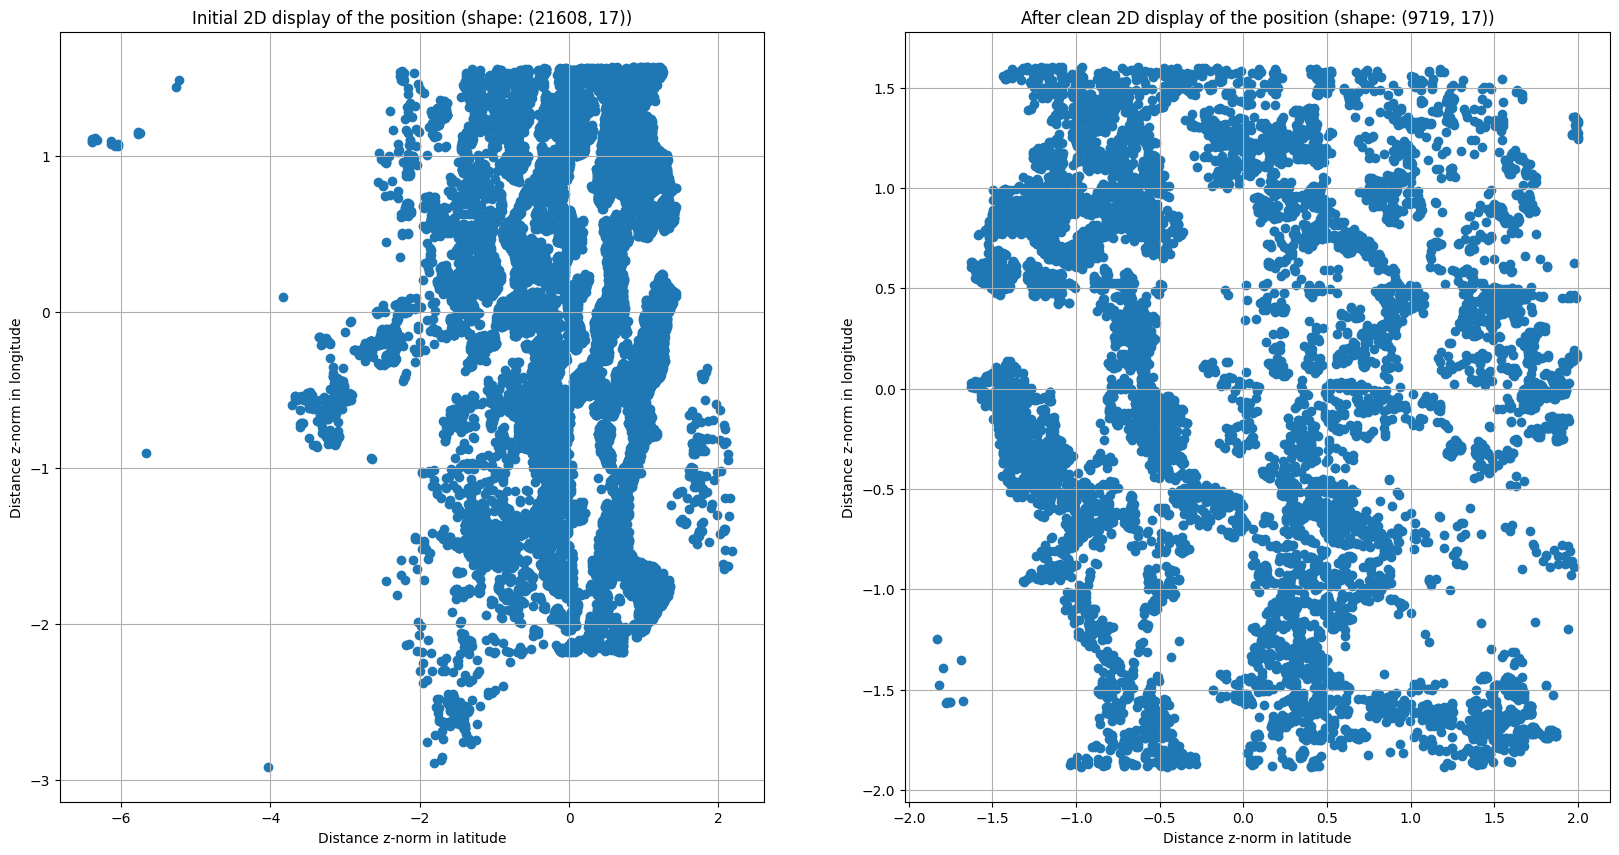

In [15]:
dz_yx = z_norm_dis(data['lat'], data['long'], lat_r, lon_r)

# plot
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.scatter(dz_yx[:,0], dz_yx[:,1])
plt.title(f'Initial 2D display of the position (shape: {data.shape})')
plt.xlabel('Distance z-norm in latitude')
plt.ylabel('Distance z-norm in longitude')
plt.grid()

dz_yx = z_norm_dis(data_clean['lat'], data_clean['long'], lat_r, lon_r)

plt.subplot(1, 2, 2)
plt.scatter(dz_yx[:,0], dz_yx[:,1])
plt.title(f'After clean 2D display of the position (shape: {data_clean.shape})')
plt.xlabel('Distance z-norm in latitude')
plt.ylabel('Distance z-norm in longitude')

plt.grid()
plt.show()

In [16]:
# create function on

def plot_comp_dataset(initial_data, after_data, item):
    
    plt.figure(figsize=(20,5))
    plt.subplot(1, 2, 1)
    plt.hist(initial_data)
    plt.title(f'The initial distribution for {item}')
    plt.xlabel('standard deviation')
    plt.ylabel('number of elements')
    plt.grid()
    
    _,_,z_item = z_score(after_data)
    
    plt.subplot(1, 2, 2)
    plt.hist(z_item)
    plt.title(f'Distribution after cleaning for {item}')
    plt.xlabel('standard deviation')
    plt.ylabel('number of elements')
    
    plt.grid()
    plt.show()

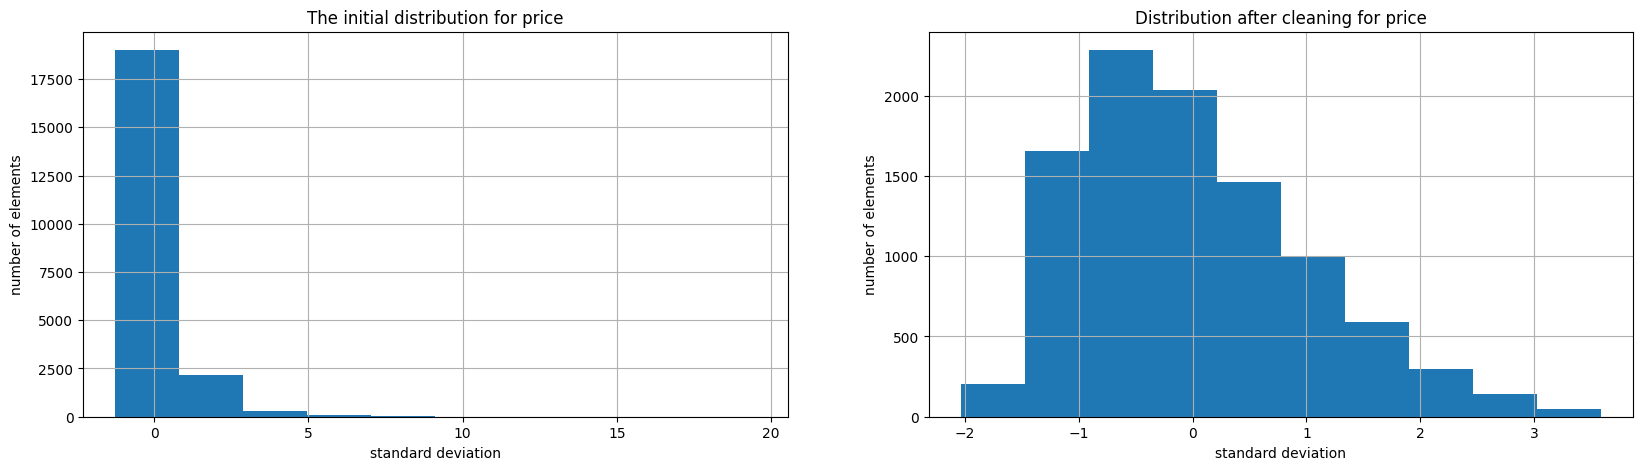

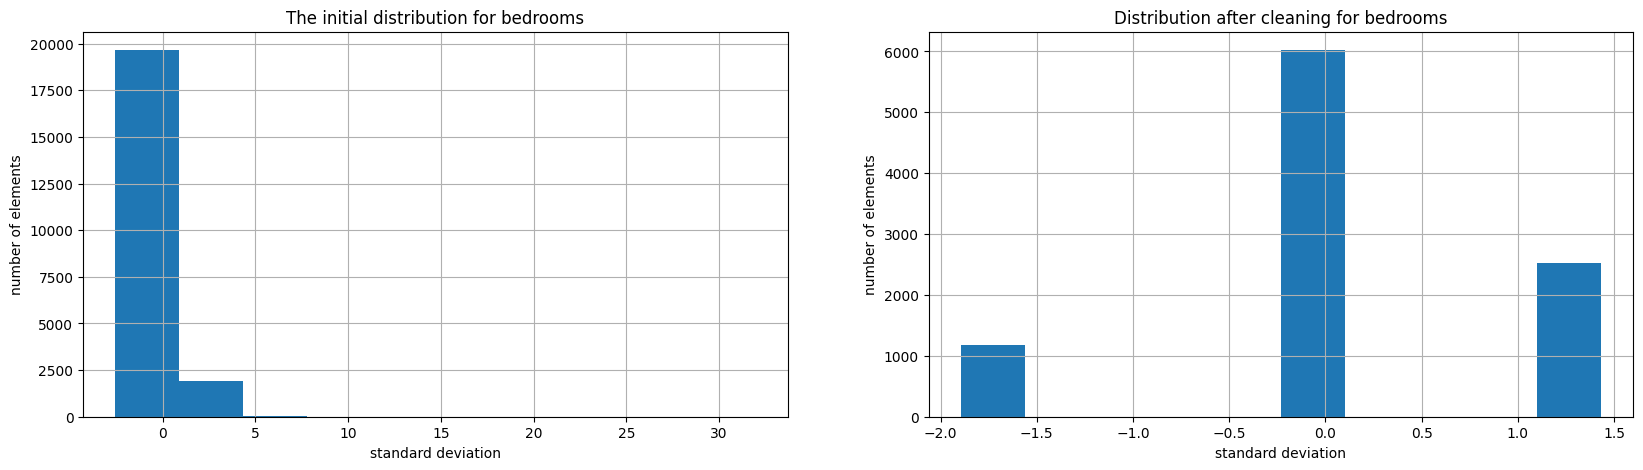

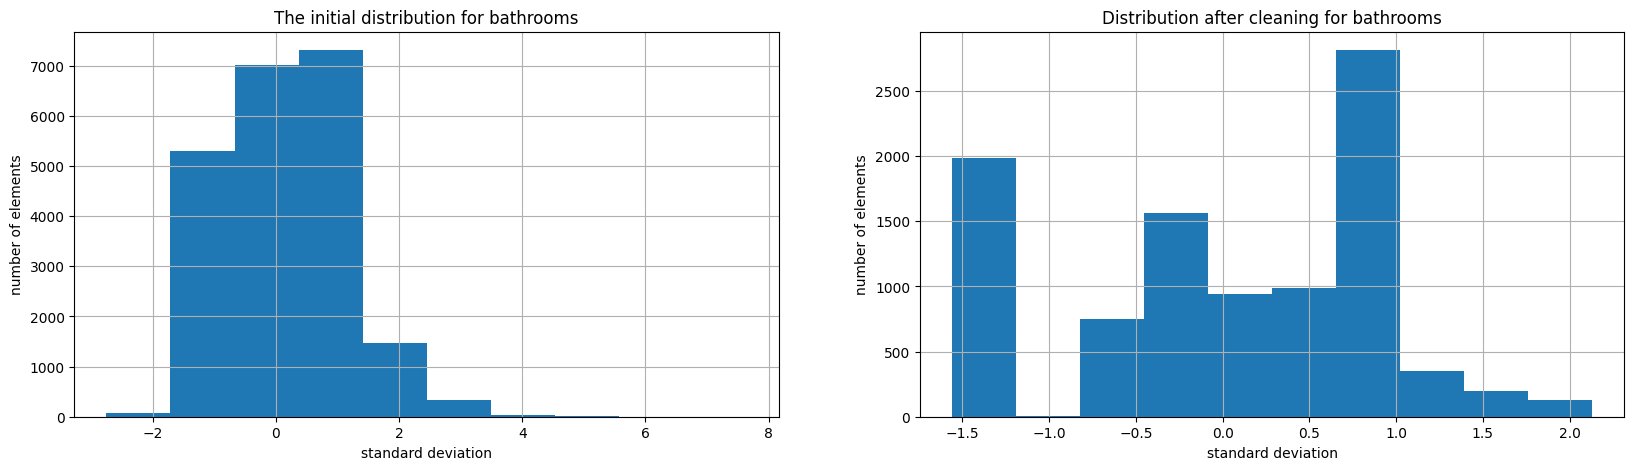

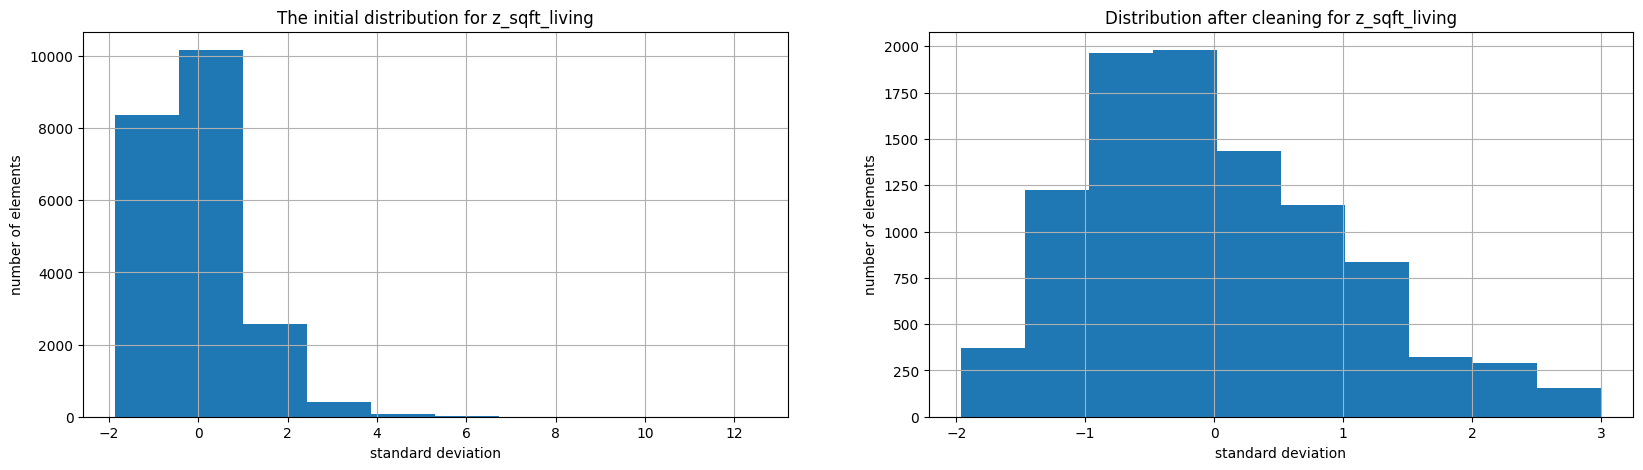

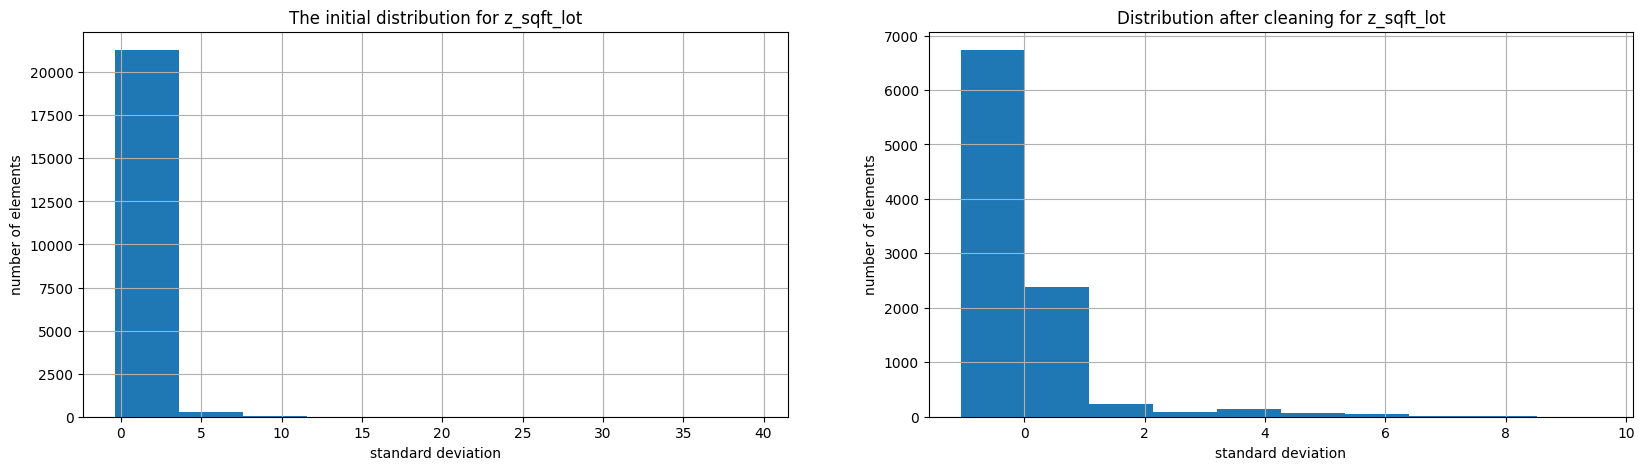

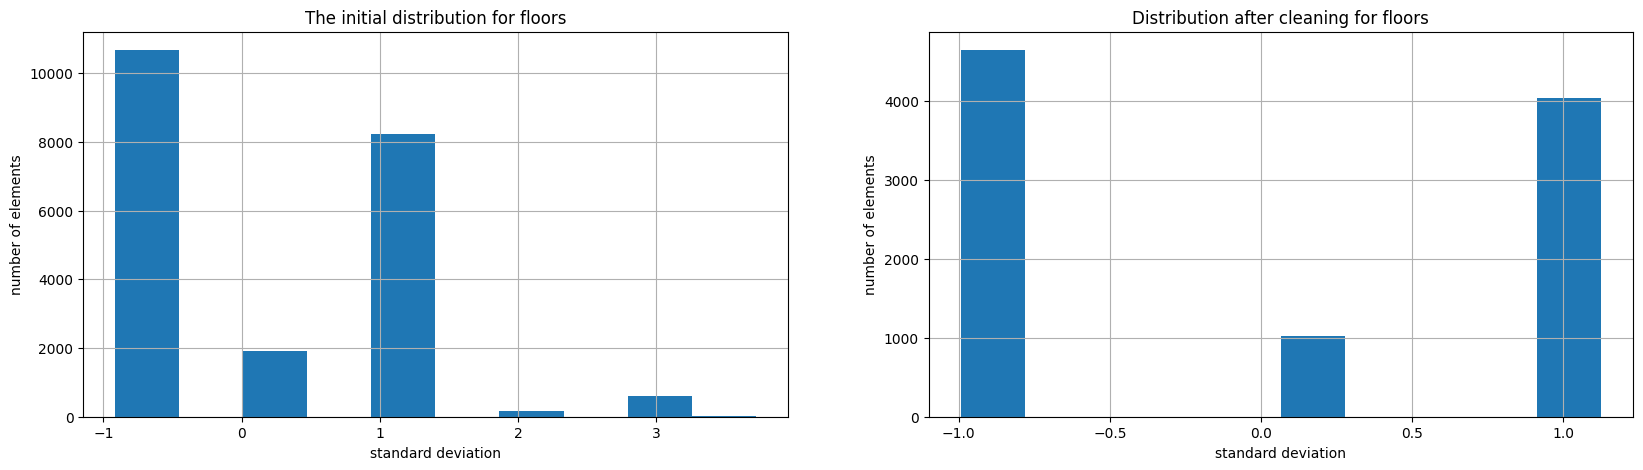

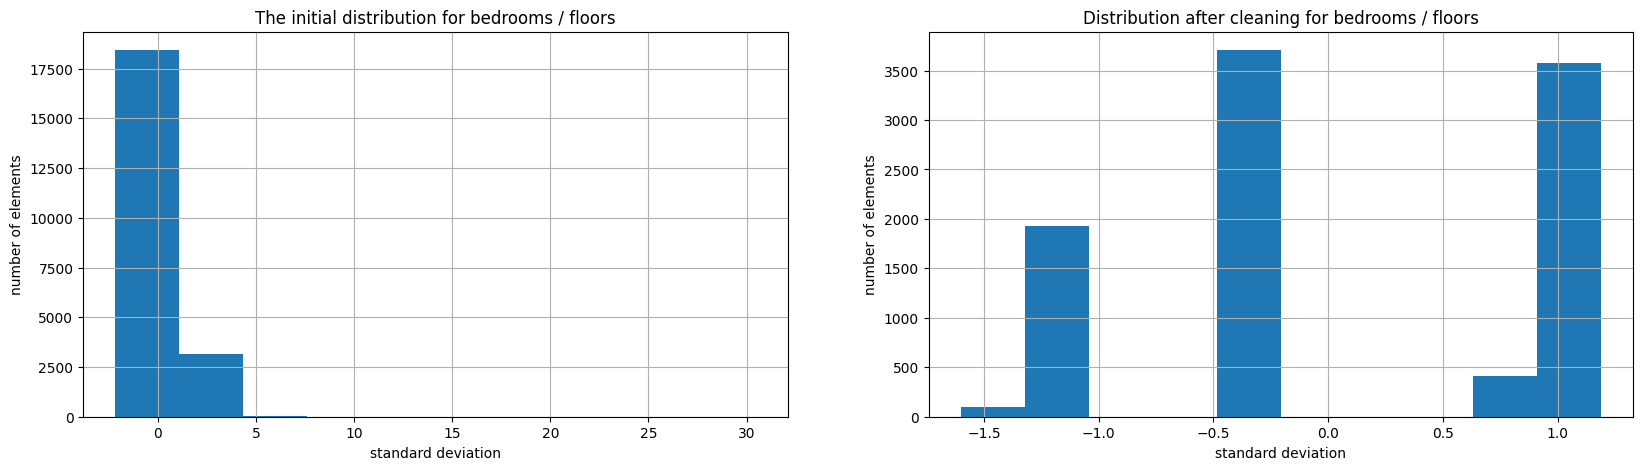

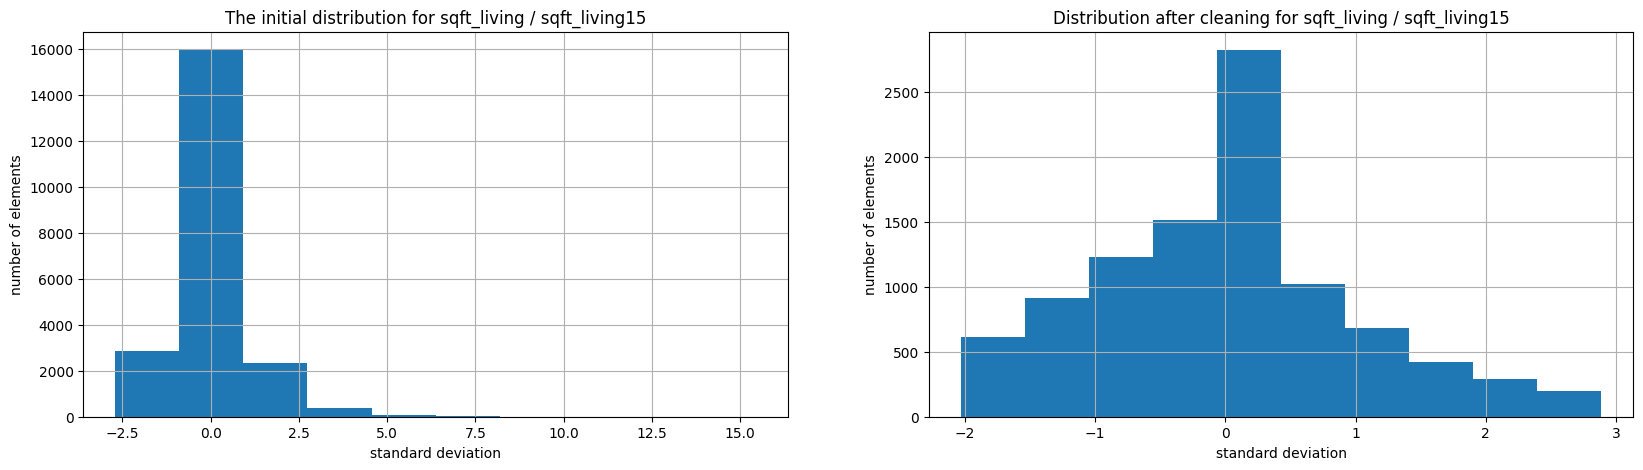

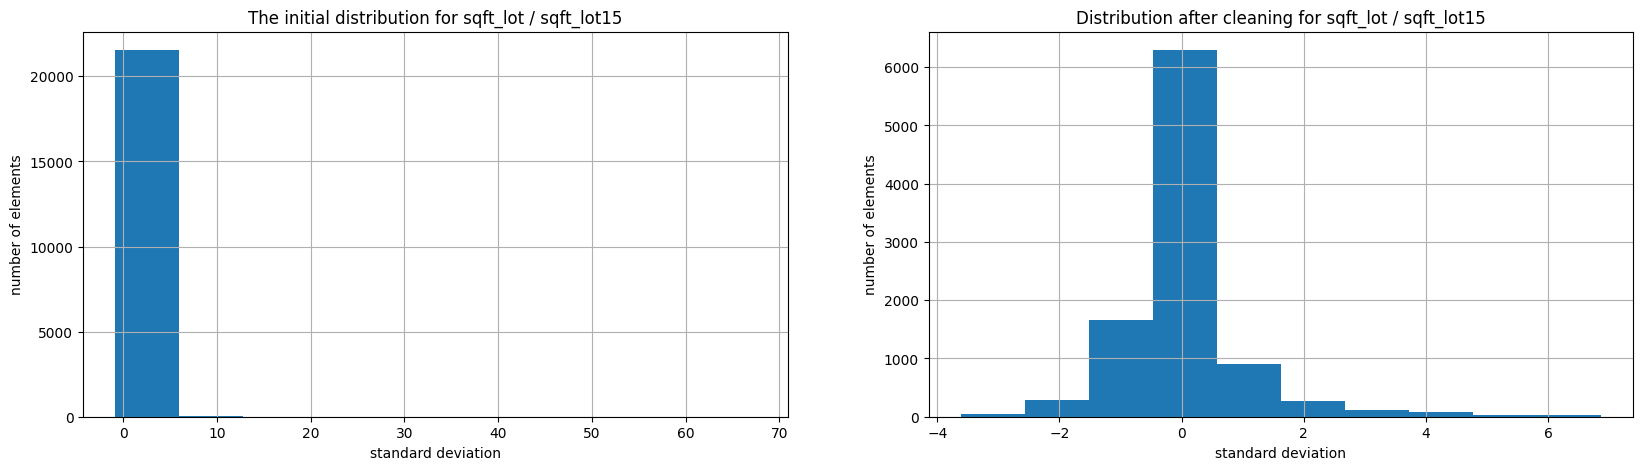

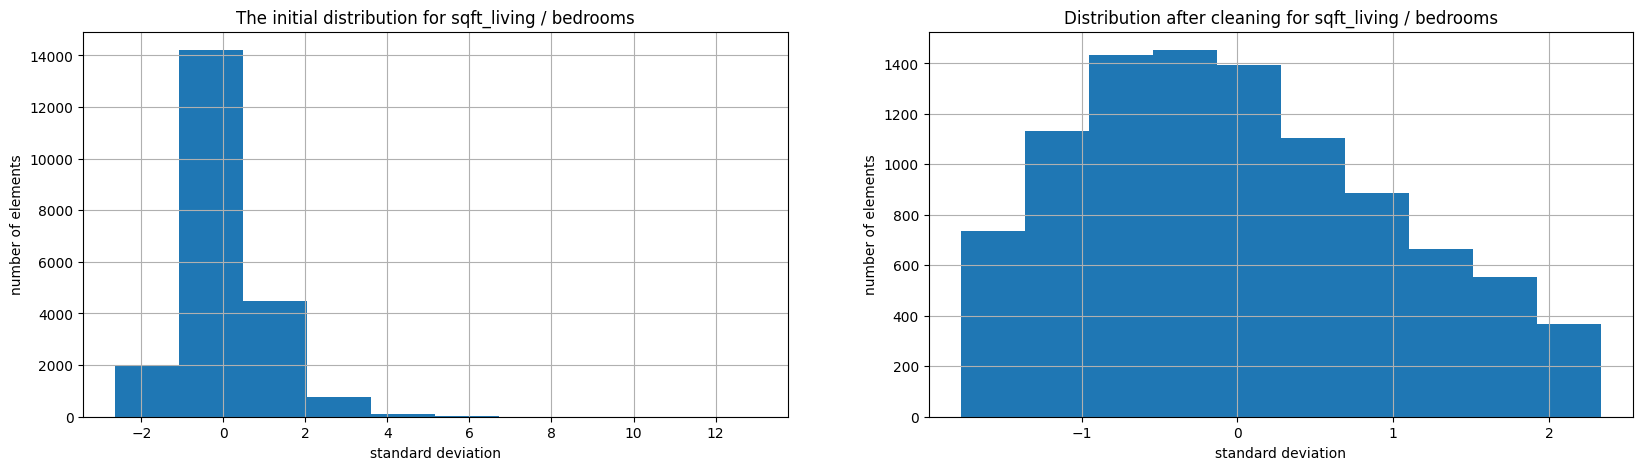

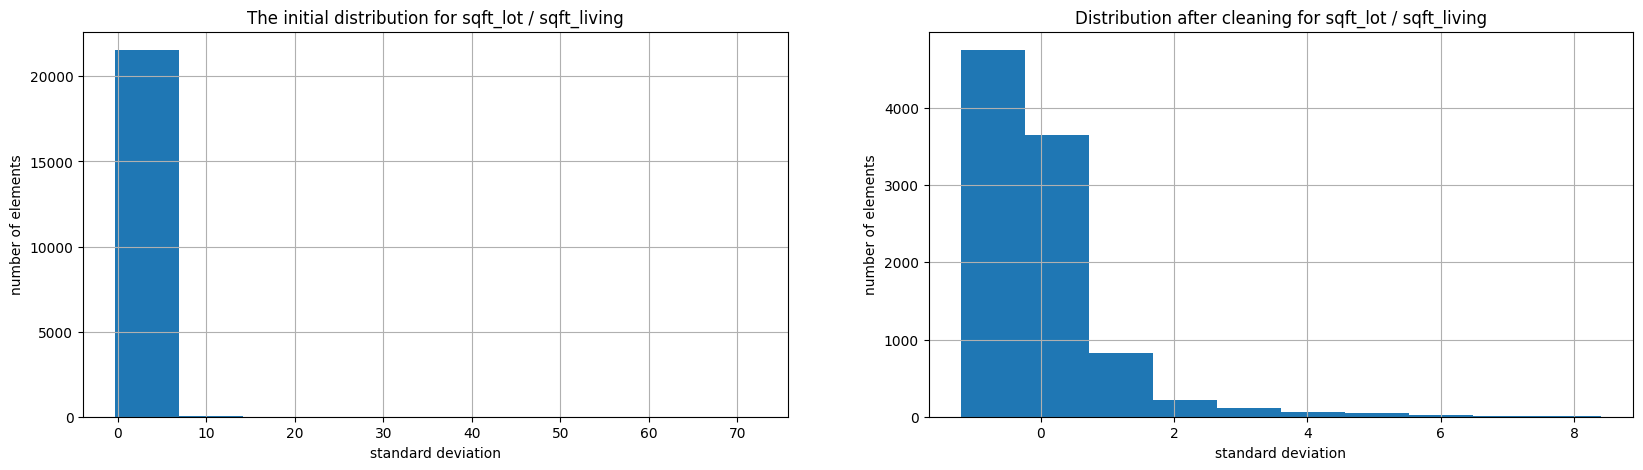

In [17]:
# execute the plotting function
plot_comp_dataset(z_price, (data_clean['price']),'price')
plot_comp_dataset(z_bedrooms, (data_clean['bedrooms']),'bedrooms')
plot_comp_dataset(z_bathrooms, (data_clean['bathrooms']),'bathrooms')
plot_comp_dataset(z_sqft_living, (data_clean['sqft_living']),'z_sqft_living')
plot_comp_dataset(z_sqft_lot, (data_clean['sqft_lot']),'z_sqft_lot')
plot_comp_dataset(z_floors, (data_clean['floors']),'floors')
plot_comp_dataset(z_bedrooms_floors, (data_clean['bedrooms']/data_clean['floors']),'bedrooms / floors')
plot_comp_dataset(z_sqft_living_living15, (data_clean['sqft_living'] / data_clean['sqft_living15']),'sqft_living / sqft_living15')
plot_comp_dataset(z_sqft_lot_lot15, (data_clean['sqft_lot'] / data_clean['sqft_lot15']),'sqft_lot / sqft_lot15')
plot_comp_dataset(z_sqft_living_bedrooms, (data_clean['sqft_living'] / data_clean['bedrooms']),'sqft_living / bedrooms')
plot_comp_dataset(z_sqft_lot_living, (data_clean['sqft_lot'] / data_clean['sqft_living']),'sqft_lot / sqft_living')

In [18]:
data_clean.to_csv('data_clean.csv', index=False)